In [1]:
from chemvae import ChemVAE, elbo_loss

from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch as T

X, y = load_boston(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = T.as_tensor(X_train).type(T.float32)
X_test = T.as_tensor(X_test).type(T.float32)

In [2]:
vae = ChemVAE()
vae.train()
opt = T.optim.Adam(vae.parameters(), lr=0.005)

for ep in range(40):

    opt.zero_grad()
    recon_x, mean, logvar = vae(X_train)
    loss_val = elbo_loss(recon_x, X_train, mean, logvar, 1.0)
    loss_val.backward()
    epoch_loss = loss_val.item()
    opt.step()

    if ep % 5 == 0:
        print(f'{ep} | {epoch_loss}')

0 | 4629.2626953125
5 | 4004.329345703125
10 | 3629.299072265625
15 | 3424.150146484375
20 | 3311.903564453125
25 | 3246.577880859375
30 | 3210.122802734375
35 | 3189.048828125


In [3]:
test_recon_x, test_mean, test_logvar = vae(X_test)
test_loss_val = elbo_loss(test_recon_x, X_test, test_mean, test_logvar, 1.0).item()
print(test_loss_val)
print()
print(X_test[0])
print()
print(test_recon_x[0])

347.5245056152344

tensor([4.1643e-04, 2.1000e-01, 1.8988e-01, 0.0000e+00, 1.1111e-01, 4.8937e-01,
        6.1895e-01, 5.1697e-01, 1.3043e-01, 1.0687e-01, 4.4681e-01, 9.9261e-01,
        2.1247e-01])

tensor([0.1020, 0.0979, 0.4041, 0.0821, 0.3463, 0.5212, 0.6454, 0.2057, 0.3848,
        0.4234, 0.6100, 0.9169, 0.2958], grad_fn=<SelectBackward>)


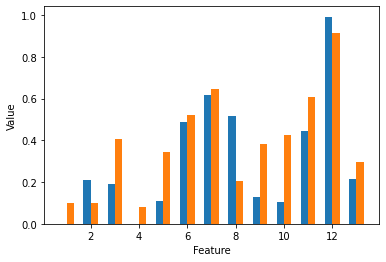

In [4]:
from matplotlib import pyplot as plt

plt.clf()
plt.bar([i + 0.85 for i in range(len(X_test[0]))], X_test[0], 0.3)
plt.bar([i + 1.15 for i in range(len(test_recon_x[0]))], test_recon_x[0].detach().numpy(), 0.3)
plt.xlabel('Feature')
plt.ylabel('Value')
plt.show()